# Calculate the metrics from the csv

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from evaluation_utils import bootstrap_from_csv
import pickle
from pathlib import Path

# --- CALCULATION ---
# Updated to match the folder structure (with "evaluation/" prefix and without "_v1")
models_to_test = {
    "DINOv2 (Video)": "csvs/dinov2_open/open_dist_matrix.csv",
    "DINOv2 (Image)": "csvs/dinov2_open_image/open_dist_matrix.csv",
    "SwinV2 (Video)": "csvs/swin_open/open_dist_matrix.csv",
    "SwinV2 (Image)": "csvs/swin_open_image/open_dist_matrix.csv",
    "ViT (Video)":    "csvs/vit_open/open_dist_matrix.csv",
    "ViT (Image)":    "csvs/vit_open_image/open_dist_matrix.csv"
}

# Dictionary to store all computed metrics
all_open_results = {}

for name, path in models_to_test.items():
    print(f"\n{'='*30}\nProcessing {name}\n{'='*30}")
    # Increased 'm' to 100 for statistically sound confidence intervals
    all_open_results[name] = bootstrap_from_csv(path, m=100, mode="open")


# --- Save Configuration ---
SAVE_DIR = Path("results_data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Define a filename (e.g., "closed_world_results.pkl")
FILENAME = f"open_world_benchmarks.pkl"
SAVE_PATH = SAVE_DIR / FILENAME

print(f"\n-> Saving all results to {SAVE_PATH}...")

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(all_open_results, f)

print("✅ Results saved successfully.")


Processing DINOv2 (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping open metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 32.50it/s]



Processing DINOv2 (Image)
-> Pre-calculating sorted match matrix...
-> Bootstrapping open metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 32.50it/s]



Processing SwinV2 (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping open metrics from CSV (100 iterations)...


...


Processing ViT (Video)
-> Pre-calculating sorted match matrix...
-> Bootstrapping open metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 33.22it/s]



Processing ViT (Image)
-> Pre-calculating sorted match matrix...
-> Bootstrapping open metrics from CSV (100 iterations)...


100%|██████████| 100/100 [00:03<00:00, 32.15it/s]


-> Saving all results to results_data\open_world_benchmarks.pkl...
✅ Results saved successfully.


In [6]:
# Load the saved data
LOAD_PATH = "results_data/open_world_benchmarks.pkl"

with open(LOAD_PATH, 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded results for: {list(all_results.keys())}")

Loaded results for: ['DINOv2 (Video)', 'DINOv2 (Image)', 'SwinV2 (Video)', 'SwinV2 (Image)', 'ViT (Video)', 'ViT (Image)']


In [7]:
for name, res in all_results.items():
    fars = res["mean_fars"]
    row_vals = []
    
    for target in [0.01, 0.05, 0.10]:
        idx = np.argmin(np.abs(fars - target))
        d_mean = res["mean_dirs"][idx]
        d_low = res["lower_dirs"][idx]
        d_high = res["upper_dirs"][idx]
        
        # CHANGED: .1% -> .3f (3 decimal places)
        val_str = f"{d_mean:.3f} [{d_low:.3f}, {d_high:.3f}]"
        row_vals.append(val_str)
    
    # target is already a ratio (0.01), so no change needed there
    print(f"{name:<25} | {row_vals[0]:<20} | {row_vals[1]:<20} | {row_vals[2]:<20}")

DINOv2 (Video)            | 0.049 [0.035, 0.064] | 0.131 [0.110, 0.151] | 0.209 [0.181, 0.238]
DINOv2 (Image)            | 0.037 [0.027, 0.048] | 0.095 [0.078, 0.114] | 0.162 [0.141, 0.194]
SwinV2 (Video)            | 0.025 [0.014, 0.035] | 0.066 [0.050, 0.082] | 0.097 [0.079, 0.120]
SwinV2 (Image)            | 0.019 [0.011, 0.028] | 0.043 [0.031, 0.056] | 0.067 [0.052, 0.082]
ViT (Video)               | 0.024 [0.012, 0.036] | 0.055 [0.039, 0.074] | 0.086 [0.065, 0.108]
ViT (Image)               | 0.009 [0.003, 0.015] | 0.035 [0.022, 0.045] | 0.062 [0.049, 0.075]


C:\Users\marko\AppData\Local\Temp\ipykernel_13344\622238624.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_results))


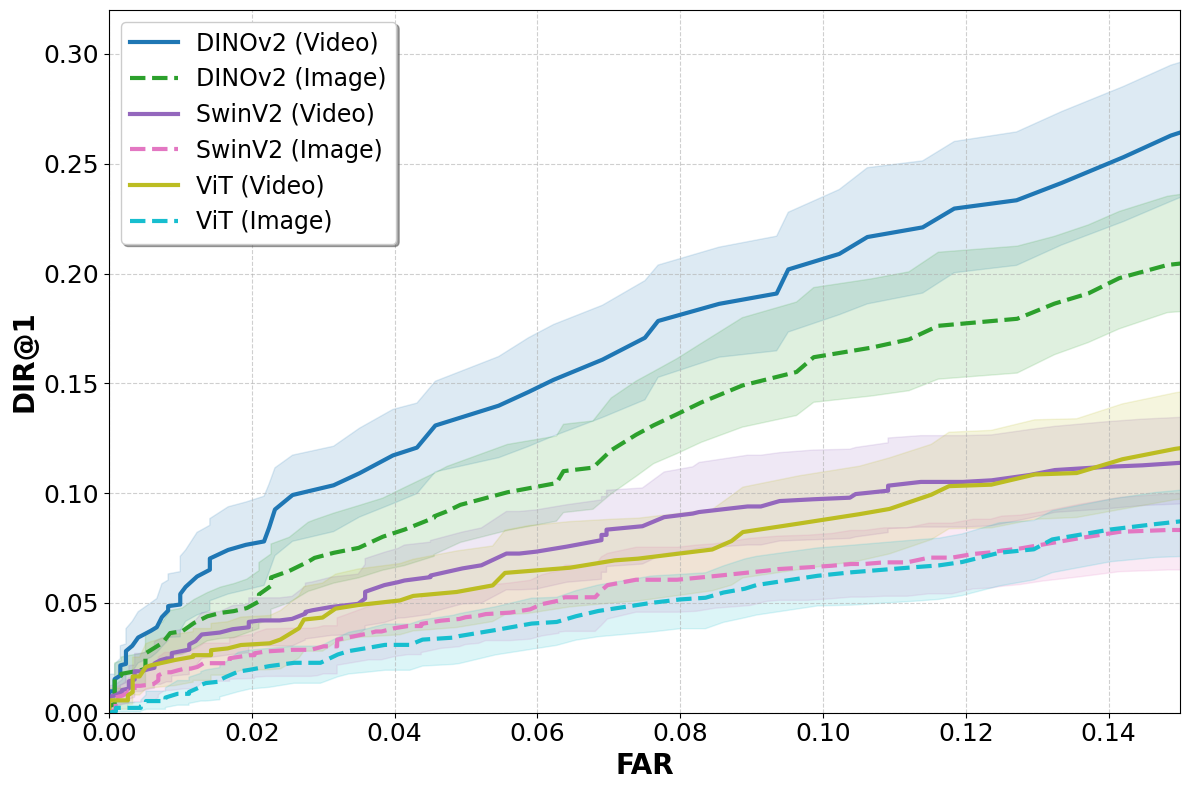

In [8]:
# -------------------------------------------------------------
# --- Plotting Configuration ---
# -------------------------------------------------------------
MAX_FAR = 0.15 
FAR_TICK_STEP = 0.02
FONT_SIZE = 18 
MAX_DIR = 0.32

# -------------------------------------------------------------
# --- Plotting Open-World Curves ---
# -------------------------------------------------------------

plt.figure(figsize=(12, 8)) # Slightly larger figure helps with large fonts
# Ensure we use the loaded dictionary name
colors = plt.cm.get_cmap('tab10', len(all_results))

for i, (name, res) in enumerate(all_results.items()):
    fars = res["mean_fars"]
    dirs = res["mean_dirs"]
    dirs_lower = res["lower_dirs"]
    dirs_upper = res["upper_dirs"]
    color = colors(i)
    
    plt.fill_between(fars, dirs_lower, dirs_upper, color=color, alpha=0.15)
    
    line_style = '-' if "(Video)" in name or "(Image)" not in name else '--'
    plt.plot(fars, dirs, color=color, linestyle=line_style, linewidth=3, label=name)

# --- Format the Plot with Larger Fonts ---
plt.xlabel("FAR", fontsize=FONT_SIZE + 2, fontweight='bold')
plt.ylabel("DIR@1", fontsize=FONT_SIZE + 2, fontweight='bold')

# --- Axis Tick Labels ---
plt.xticks(np.arange(0, MAX_FAR + 0.01, step=FAR_TICK_STEP), fontsize=FONT_SIZE)
plt.yticks(fontsize=FONT_SIZE)

# --- Dynamic Axis Control ---
plt.xlim(0, MAX_FAR) 
plt.ylim(0, MAX_DIR) # Increased to 0.40 to ensure the legend doesn't overlap lines

plt.grid(True, linestyle='--', alpha=0.6)

# --- Legend Configuration ---
# loc='upper left' as requested, with a slightly smaller font than the axis labels
plt.legend(fontsize=FONT_SIZE - 1, loc='upper left', frameon=True, shadow=True, facecolor='white')

plt.tight_layout()
plt.savefig("figs/open_world.png")
plt.show()